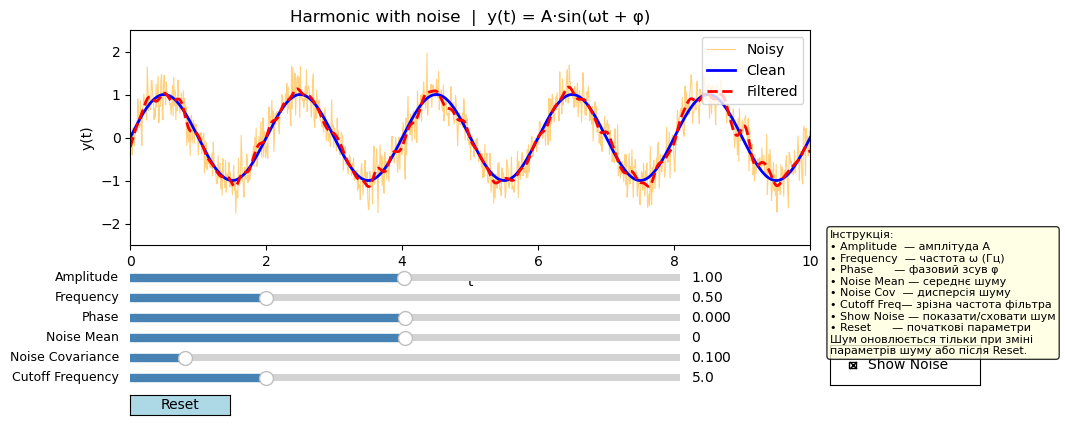

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy import signal

# початкові параметри
INIT = dict(amplitude=1.0, frequency=0.5, phase=0.0,
            noise_mean=0.0, noise_covariance=0.1, cutoff=5.0)

t = np.linspace(0, 10, 1000)
_noise_cache = None          # кешований шум


def harmonic_with_noise(amplitude, frequency, phase,
                        noise_mean, noise_covariance, show_noise):
    """Повертає чисту гармоніку і гармоніку з шумом."""
    global _noise_cache
    clean = amplitude * np.sin(2 * np.pi * frequency * t + phase)
    if _noise_cache is None:
        _noise_cache = np.random.normal(noise_mean,
                                        np.sqrt(noise_covariance), len(t))
    noisy = clean + _noise_cache
    return clean, noisy


def apply_filter(noisy_signal, cutoff, fs=100.0):
    """Фільтрує сигнал за допомогою IIR low-pass фільтра Баттерворта."""
    nyq = fs / 2
    norm_cutoff = min(cutoff / nyq, 0.99)
    b, a = signal.butter(4, norm_cutoff, btype='low', analog=False)
    return signal.filtfilt(b, a, noisy_signal)


# фігура і осі
fig, ax = plt.subplots(figsize=(10, 5))
plt.subplots_adjust(left=0.1, bottom=0.52, right=0.78, top=0.95)

ax.set_xlim(0, 10)
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel("t")
ax.set_ylabel("y(t)")
ax.set_title("Harmonic with noise  |  y(t) = A·sin(ωt + φ)")

# перший рендер
clean0, noisy0 = harmonic_with_noise(
    amplitude=INIT['amplitude'], frequency=INIT['frequency'],
    phase=INIT['phase'], noise_mean=INIT['noise_mean'],
    noise_covariance=INIT['noise_covariance'], show_noise=True)
filtered0 = apply_filter(noisy0, INIT['cutoff'])

line_noise,  = ax.plot(t, noisy0,    color='orange',  alpha=0.5,
                        linewidth=0.8, label='Noisy')
line_clean,  = ax.plot(t, clean0,    color='blue',    linewidth=2,
                        label='Clean')
line_filtered, = ax.plot(t, filtered0, color='red', linewidth=2,
                          linestyle='--', label='Filtered')
ax.legend(loc='upper right')

# слайдери
slider_specs = [
    ('Amplitude',        0.01, 2.0,  INIT['amplitude'],        0.44),
    ('Frequency',        0.01, 2.0,  INIT['frequency'],        0.40),
    ('Phase',           -np.pi, np.pi, INIT['phase'],           0.36),
    ('Noise Mean',      -1.0,  1.0,  INIT['noise_mean'],       0.32),
    ('Noise Covariance', 0.001, 1.0,  INIT['noise_covariance'], 0.28),
    ('Cutoff Frequency', 0.1,  20.0, INIT['cutoff'],           0.24),
]

sliders = {}
for label, vmin, vmax, vinit, ypos in slider_specs:
    ax_s = plt.axes([0.1, ypos, 0.55, 0.03])
    sl = Slider(ax_s, label, vmin, vmax, valinit=vinit, color='steelblue')
    sl.label.set_fontsize(9)
    sliders[label] = sl

# чекбокс Show Noise
ax_check = plt.axes([0.80, 0.24, 0.15, 0.08])
check = CheckButtons(ax_check, ['Show Noise'], [True])

# кнопка Reset
ax_btn = plt.axes([0.10, 0.18, 0.10, 0.04])
btn_reset = Button(ax_btn, 'Reset', color='lightblue')


# оновлення графіка
def update(val=None, noise_changed=False):
    global _noise_cache

    amp  = sliders['Amplitude'].val
    freq = sliders['Frequency'].val
    ph   = sliders['Phase'].val
    nm   = sliders['Noise Mean'].val
    ncov = sliders['Noise Covariance'].val
    cutoff = sliders['Cutoff Frequency'].val
    show = check.get_status()[0]

    # якщо змінились параметри шуму — скидаємо кеш
    if noise_changed:
        _noise_cache = None

    clean, noisy = harmonic_with_noise(amp, freq, ph, nm, ncov, show)
    filtered = apply_filter(noisy, cutoff)

    line_clean.set_ydata(clean)
    line_noise.set_ydata(noisy)
    line_noise.set_visible(show)
    line_filtered.set_ydata(filtered)
    fig.canvas.draw_idle()


def on_noise_slider(val):
    """Викликається при зміні слайдерів шуму — скидає кеш."""
    update(noise_changed=True)


def reset(event):
    global _noise_cache
    _noise_cache = None
    for label, _, _, vinit, _ in slider_specs:
        sliders[label].set_val(vinit)
    if not check.get_status()[0]:
        check.set_active(0)        # включити Show Noise
    update()


# прив'язка слайдерів
sliders['Amplitude'].on_changed(update)
sliders['Frequency'].on_changed(update)
sliders['Phase'].on_changed(update)
sliders['Noise Mean'].on_changed(on_noise_slider)
sliders['Noise Covariance'].on_changed(on_noise_slider)
sliders['Cutoff Frequency'].on_changed(update)

check.on_clicked(update)
btn_reset.on_clicked(reset)

# інструкція
instructions = (
    "Інструкція:\n"
    "• Amplitude  — амплітуда A\n"
    "• Frequency  — частота ω (Гц)\n"
    "• Phase      — фазовий зсув φ\n"
    "• Noise Mean — середнє шуму\n"
    "• Noise Cov  — дисперсія шуму\n"
    "• Cutoff Freq— зрізна частота фільтра\n"
    "• Show Noise — показати/сховати шум\n"
    "• Reset      — початкові параметри\n"
    "Шум оновлюється тільки при зміні\n"
    "параметрів шуму або після Reset."
)
fig.text(0.80, 0.55, instructions, fontsize=8,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.show()